# RetailHero Exploratory Data Analysis

## Objective

This notebook explores the cleaned RetailHero data to support feature engineering for uplift modeling.

The modeling population is defined by `uplift_train`, which contains the customers with observed treatment assignment and purchase outcome. Customer information, purchase history, and product metadata are restricted to this population before the analysis begins.

The analysis follows this workflow:

```text
Cleaned RetailHero data
        ↓
Define experiment population
        ↓
Experiment sanity check
        ↓
Broad data overview
        ↓
Customer-level behavioral EDA
        ↓
Treatment-Control analysis
        ↓
Feature-engineering implications

### RetailHero Data Structure

The cleaned RetailHero data consists of four tables:

- `clients`: customer information
- `products`: product metadata
- `purchases`: historical purchases recorded before the promotional communication
- `uplift_train`: treatment assignment and observed outcome for the labeled experiment customers

The tables are connected through `client_id` and `product_id`.

```text
uplift_train
      │
      │ client_id
      ▼
   clients

uplift_train
      │
      │ client_id
      ▼
  purchases ─── product_id ───► products
```

The final modeling decision is made at the customer level. Purchase and product tables therefore remain at their original grain during exploration and are aggregated to customer-level features only when needed.

In [86]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [87]:
TABLE_HIGHLIGHT = {
    "blue": {"background-color": "#1976D2", "color": "white", "font-weight": "700"},
    "red": {"background-color": "#D32F2F", "color": "white", "font-weight": "700"},
}

COLORS = {
    "pacific_green": "#017360",
    "rainy_lake": "#446E8F",
    "serene_sea": "#77A7C4",
    "sora_blue": "#A1DBF1",
    "afterglow": "#F2E6CE",
    "bungalow_maple": "#F3D094",
}


def style_table(df: pd.DataFrame, formats: dict | None = None):
    return df.style.hide(axis="index").format(formats or {}, na_rep="—")


def paint(styler, rows, columns, style_key: str):
    rows = list(rows)
    if not rows:
        return styler

    columns = [columns] if isinstance(columns, str) else list(columns)
    return styler.set_properties(
        subset=pd.IndexSlice[rows, columns],
        **TABLE_HIGHLIGHT[style_key],
    )


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [88]:
PROJECT_ROOT = Path.cwd().parents[1]

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim" / "retailhero"
CLEAN_DATA_DIR = INTERIM_DATA_DIR / "clean"

CLEAN_FILES = {
    "clients": CLEAN_DATA_DIR / "clients_clean.parquet",
    "products": CLEAN_DATA_DIR / "products_clean.parquet",
    "purchases": CLEAN_DATA_DIR / "purchases_clean.parquet",
    "uplift_train": CLEAN_DATA_DIR / "uplift_train_clean.parquet",
}

missing_files = [
    f"{name}: {path}"
    for name, path in CLEAN_FILES.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing RetailHero cleaned files:\n" + "\n".join(missing_files)
    )

print("Project root:", PROJECT_ROOT)
print("Clean data:", CLEAN_DATA_DIR)

Project root: d:\thao\d\uplif_model\uplif_customer_selection
Clean data: d:\thao\d\uplif_model\uplif_customer_selection\data\interim\retailhero\clean


In [89]:
duckdb_connection = duckdb.connect()

for table_name, path in CLEAN_FILES.items():
    duckdb_connection.execute(
        f"""
        CREATE OR REPLACE VIEW {table_name}_clean AS
        SELECT *
        FROM read_parquet('{path.as_posix()}')
        """
    )

## Define Experiment Population

The labeled uplift experiment is defined by `uplift_train`.

Before starting the EDA, all supporting tables are explicitly restricted to these customers:

- `clients` keeps only experiment customers
- `purchases` keeps only their historical purchases
- `products` keeps only products appearing in those purchase histories.

This creates a consistent analysis scope while preserving the original grain of each table.

In [90]:
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW uplift_train AS
    SELECT *
    FROM uplift_train_clean
    """
)

duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW clients AS
    SELECT c.*
    FROM clients_clean AS c
    INNER JOIN uplift_train AS u USING (client_id)
    """
)

duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW purchases AS
    SELECT p.*
    FROM purchases_clean AS p
    INNER JOIN uplift_train AS u USING (client_id)
    """
)

duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW products AS
    SELECT pr.*
    FROM products_clean AS pr
    INNER JOIN (
        SELECT DISTINCT product_id
        FROM purchases
    ) AS p USING (product_id)
    """
)

In [91]:
analysis_relations = {
    "clients": "clients",
    "products": "products",
    "purchases": "purchases",
    "uplift_train": "uplift_train",
}

scope_overview = []

for table_name, relation_name in analysis_relations.items():
    rows = duckdb_connection.execute(
        f"SELECT COUNT(*) FROM {relation_name}"
    ).fetchone()[0]

    columns = len(
        duckdb_connection.execute(
            f"DESCRIBE {relation_name}"
        ).df()
    )

    scope_overview.append({
        "table": table_name,
        "rows": rows,
        "columns": columns,
    })

scope_overview = pd.DataFrame(scope_overview)

display(
    style_table(
        scope_overview,
        formats={"rows": "{:,.0f}"},
    )
)

table,rows,columns
clients,"200,039",5
products,"40,716",11
purchases,"22,882,690",12
uplift_train,"200,039",3


## Experiment Sanity Check

Before exploring customer behavior, first take a quick look at the labeled uplift experiment.

- How customers are divided between Treatment and Control
- How common the positive outcome is
- Whether the observed purchase rate differs between the two groups.

experiment_group,customers,percentage
Control,"100,058",50.02%
Treatment,"99,981",49.98%


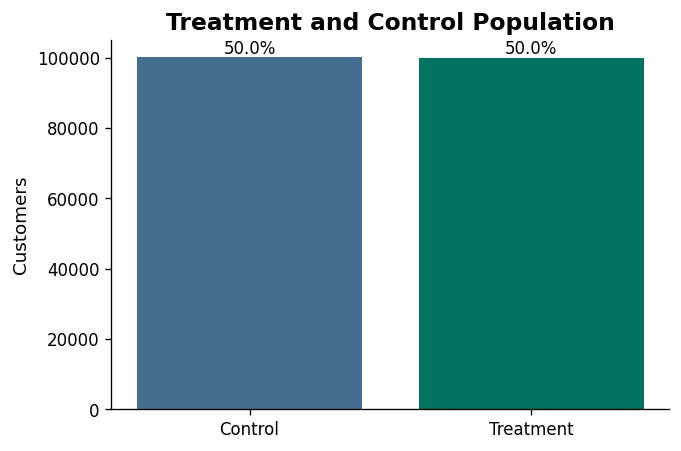

In [92]:
treatment_distribution = duckdb_connection.execute(
    """
    SELECT
        CASE
            WHEN treatment_flg = 0 THEN 'Control'
            WHEN treatment_flg = 1 THEN 'Treatment'
        END AS experiment_group,
        COUNT(*) AS customers,
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS percentage
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

display(
    style_table(
        treatment_distribution,
        formats={
            "customers": "{:,.0f}",
            "percentage": "{:.2f}%",
        },
    )
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    treatment_distribution["experiment_group"],
    treatment_distribution["customers"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

for bar, percentage in zip(
    bars,
    treatment_distribution["percentage"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Treatment and Control Population")
plt.ylabel("Customers")
plt.show()

experiment_group,customers,positive_outcomes,positive_outcome_rate
Control,"100,058","60,363",60.33%
Treatment,"99,981","63,639",63.65%


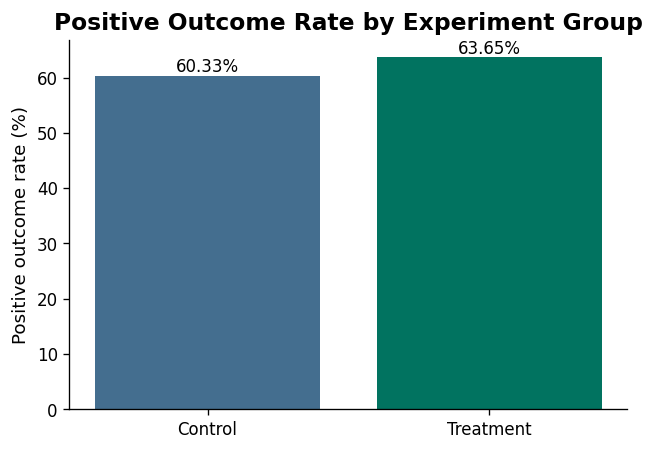

In [93]:
outcome_by_treatment = duckdb_connection.execute(
    """
    SELECT
        CASE
            WHEN treatment_flg = 0 THEN 'Control'
            WHEN treatment_flg = 1 THEN 'Treatment'
        END AS experiment_group,
        COUNT(*) AS customers,
        SUM(target) AS positive_outcomes,
        100.0 * AVG(target) AS positive_outcome_rate
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

display(
    style_table(
        outcome_by_treatment,
        formats={
            "customers": "{:,.0f}",
            "positive_outcomes": "{:,.0f}",
            "positive_outcome_rate": "{:.2f}%",
        },
    )
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    outcome_by_treatment["experiment_group"],
    outcome_by_treatment["positive_outcome_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

for bar, rate in zip(
    bars,
    outcome_by_treatment["positive_outcome_rate"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom",
    )

plt.title("Positive Outcome Rate by Experiment Group")
plt.ylabel("Positive outcome rate (%)")
plt.show()

The start and end timestamps are fixed here and reused consistently in the later customer-level analysis.

In [94]:
analysis_window = duckdb_connection.execute(
    """
    SELECT
        MIN(transaction_datetime) AS analysis_start,
        MAX(transaction_datetime) AS analysis_end
    FROM purchases
    """
).df()

ANALYSIS_START_TIMESTAMP = analysis_window.loc[0, "analysis_start"]
ANALYSIS_END_TIMESTAMP = analysis_window.loc[0, "analysis_end"]

display(analysis_window)

print("Analysis start:", ANALYSIS_START_TIMESTAMP)
print("Analysis end:", ANALYSIS_END_TIMESTAMP)

,analysis_start,analysis_end
0,2018-11-21 21:02:33,2019-03-18 23:19:28


Analysis start: 2018-11-21 21:02:33
Analysis end: 2019-03-18 23:19:28


### Experiment Overview

The experiment contains **200,039 customers** and is almost evenly split between Control (**50.02%**) and Treatment (**49.98%**).

The positive outcome rate is **60.33% for Control** and **63.65% for Treatment**, giving an observed difference of about **3.3 percentage points**. This suggests that the treatment may have a positive overall effect, while the later analysis will examine whether this effect differs across customer groups.

The available purchase history covers **21 November 2018 to 18 March 2019**. This period is fixed as the pre-treatment analysis window and will be used consistently in the following EDA and feature engineering steps.

## Broad Data Overview

Before analyzing customer behavior in detail, first take a simple look at the scale and composition of the available data.


In [95]:
dataset_overview = duckdb_connection.execute(
    """
    SELECT
        (SELECT COUNT(*) FROM clients) AS customers,
        (SELECT COUNT(DISTINCT transaction_id) FROM purchases) AS transactions,
        (SELECT COUNT(*) FROM purchases) AS purchase_lines,
        (SELECT COUNT(*) FROM products) AS products,
        (SELECT COUNT(DISTINCT store_id) FROM purchases) AS stores
    """
).df()

display(
    style_table(
        dataset_overview,
        formats={
            "customers": "{:,.0f}",
            "transactions": "{:,.0f}",
            "purchase_lines": "{:,.0f}",
            "products": "{:,.0f}",
            "stores": "{:,.0f}",
        },
    )
)

customers,transactions,purchase_lines,products,stores
"200,039","4,024,941","22,882,690","40,716","13,879"


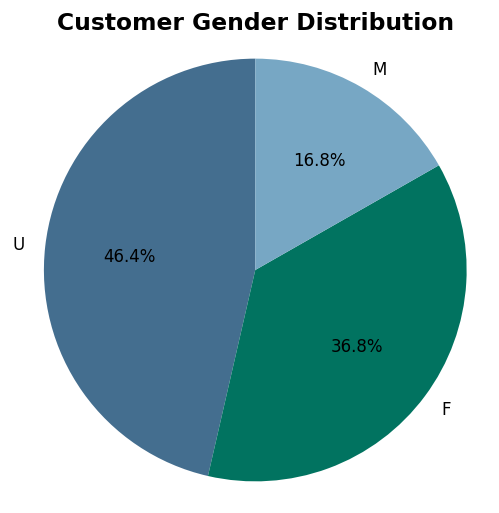

In [96]:
gender_distribution = duckdb_connection.execute(
    """
    SELECT
        gender,
        COUNT(*) AS customers,
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS percentage
    FROM clients
    GROUP BY gender
    ORDER BY customers DESC
    """
).df()

plt.figure(figsize=(5, 5))

plt.pie(
    gender_distribution["customers"],
    labels=gender_distribution["gender"],
    autopct="%1.1f%%",  
    startangle=90,       
    colors=[COLORS["rainy_lake"], COLORS["pacific_green"], COLORS["serene_sea"]], 
)

plt.title("Customer Gender Distribution")
plt.axis("equal")  
plt.show()

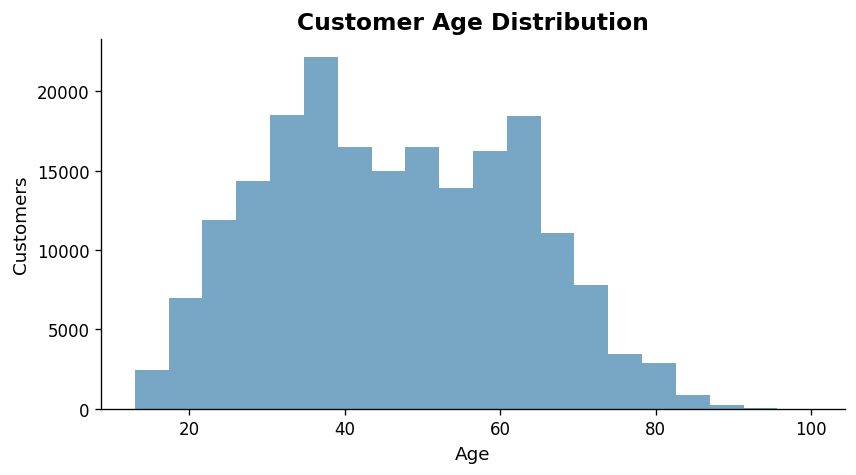

In [97]:
customer_age = duckdb_connection.execute(
    """
    SELECT age
    FROM clients
    WHERE age IS NOT NULL
    """
).df()

plt.figure(figsize=(8, 4))

plt.hist(
    customer_age["age"],
    bins=20,
    color=COLORS["serene_sea"],
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()

In [98]:
duckdb_connection.execute(
    """
    CREATE OR REPLACE VIEW transactions AS
    SELECT DISTINCT
        client_id,
        transaction_id,
        transaction_datetime,
        store_id
    FROM purchases
    """
)

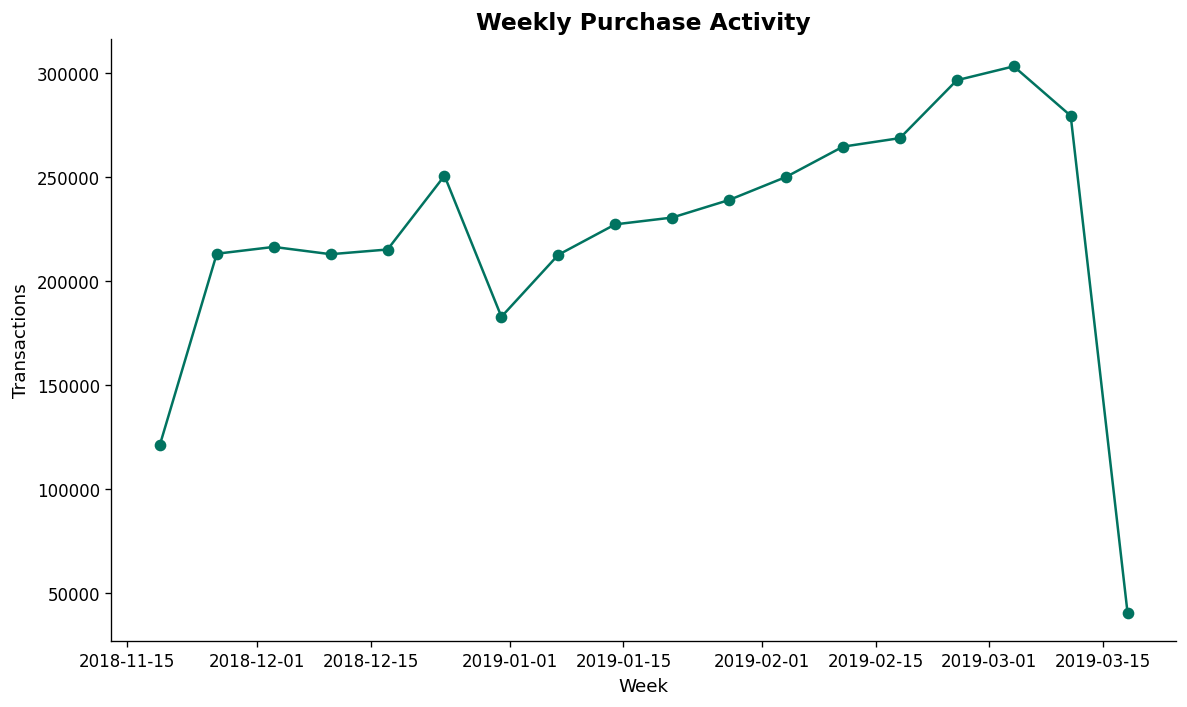

In [99]:
weekly_purchase_activity = duckdb_connection.execute(
    """
    SELECT
        DATE_TRUNC('week', transaction_datetime) AS week,
        COUNT(*) AS transactions
    FROM transactions
    GROUP BY week
    ORDER BY week
    """
).df()

plt.figure(figsize=(10, 6))

plt.plot(
    weekly_purchase_activity["week"],
    weekly_purchase_activity["transactions"],
    marker="o",
    color=COLORS["pacific_green"],
)

plt.title("Weekly Purchase Activity")
plt.xlabel("Week")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()

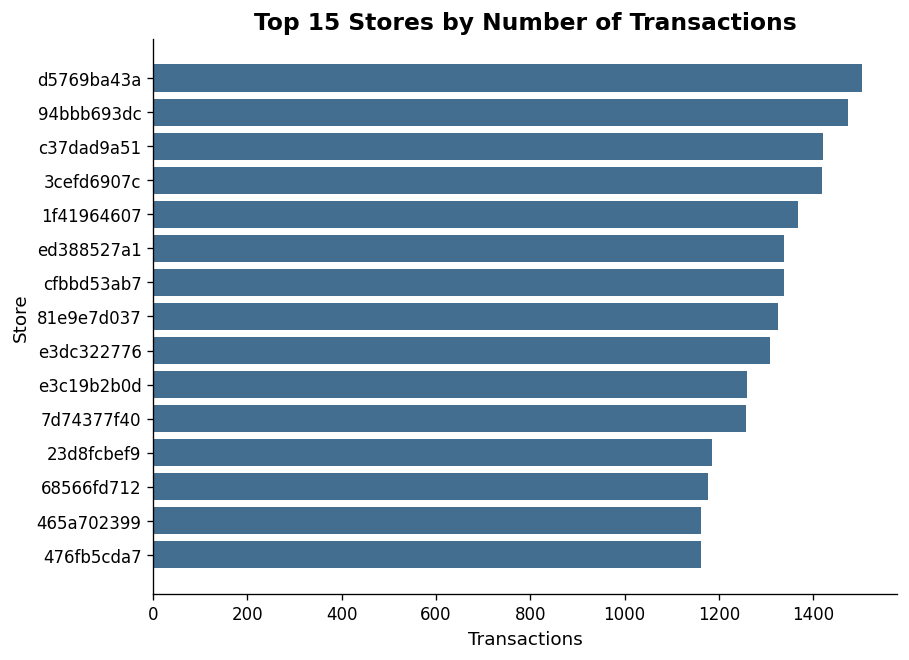

In [100]:
store_activity = duckdb_connection.execute(
    """
    SELECT
        store_id,
        COUNT(*) AS transactions
    FROM transactions
    GROUP BY store_id
    ORDER BY transactions DESC
    LIMIT 15
    """
).df()

store_activity = store_activity.sort_values(
    "transactions",
    ascending=True,
)

plt.figure(figsize=(8, 6))

plt.barh(
    store_activity["store_id"],
    store_activity["transactions"],
    color=COLORS["rainy_lake"],
)

plt.title("Top 15 Stores by Number of Transactions")
plt.xlabel("Transactions")
plt.ylabel("Store")
plt.show()

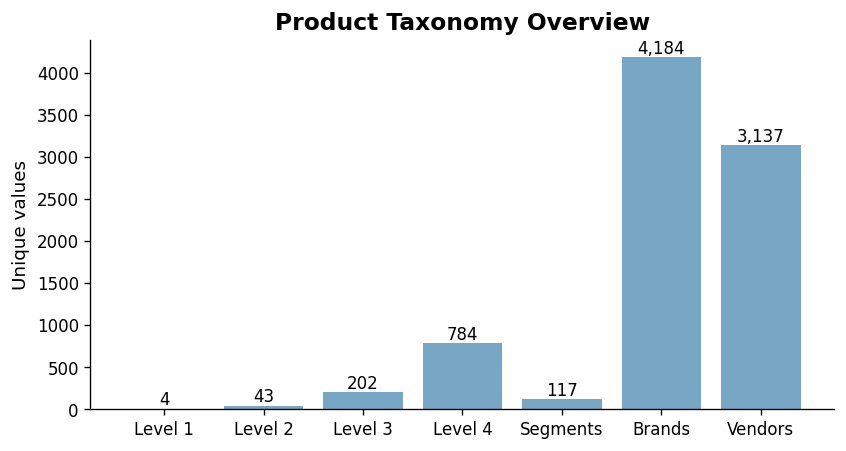

In [101]:
product_taxonomy = duckdb_connection.execute(
    """
    SELECT 'Level 1' AS category_level, COUNT(DISTINCT level_1) AS categories
    FROM products

    UNION ALL

    SELECT 'Level 2', COUNT(DISTINCT level_2)
    FROM products

    UNION ALL

    SELECT 'Level 3', COUNT(DISTINCT level_3)
    FROM products

    UNION ALL

    SELECT 'Level 4', COUNT(DISTINCT level_4)
    FROM products

    UNION ALL

    SELECT 'Segments', COUNT(DISTINCT segment_id)
    FROM products

    UNION ALL

    SELECT 'Brands', COUNT(DISTINCT brand_id)
    FROM products

    UNION ALL

    SELECT 'Vendors', COUNT(DISTINCT vendor_id)
    FROM products
    """
).df()

plt.figure(figsize=(8, 4))

bars = plt.bar(
    product_taxonomy["category_level"],
    product_taxonomy["categories"],
    color=COLORS["serene_sea"],
)

for bar, count in zip(
    bars,
    product_taxonomy["categories"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,.0f}",
        ha="center",
        va="bottom",
    )

plt.title("Product Taxonomy Overview")
plt.ylabel("Unique values")
plt.show()

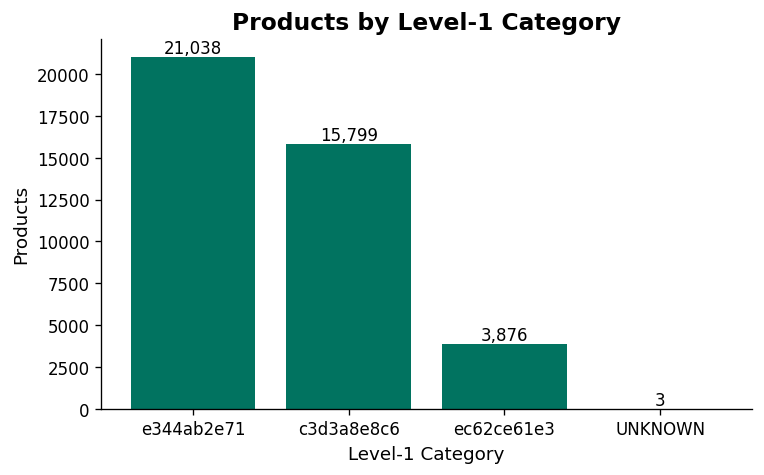

In [102]:
level_1_distribution = duckdb_connection.execute(
    """
    SELECT
        level_1,
        COUNT(*) AS products
    FROM products
    GROUP BY level_1
    ORDER BY products DESC
    """
).df()

plt.figure(figsize=(7, 4))

bars = plt.bar(
    level_1_distribution["level_1"],
    level_1_distribution["products"],
    color=COLORS["pacific_green"],
)

for bar, count in zip(
    bars,
    level_1_distribution["products"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,.0f}",
        ha="center",
        va="bottom",
    )

plt.title("Products by Level-1 Category")
plt.xlabel("Level-1 Category")
plt.ylabel("Products")
plt.show()

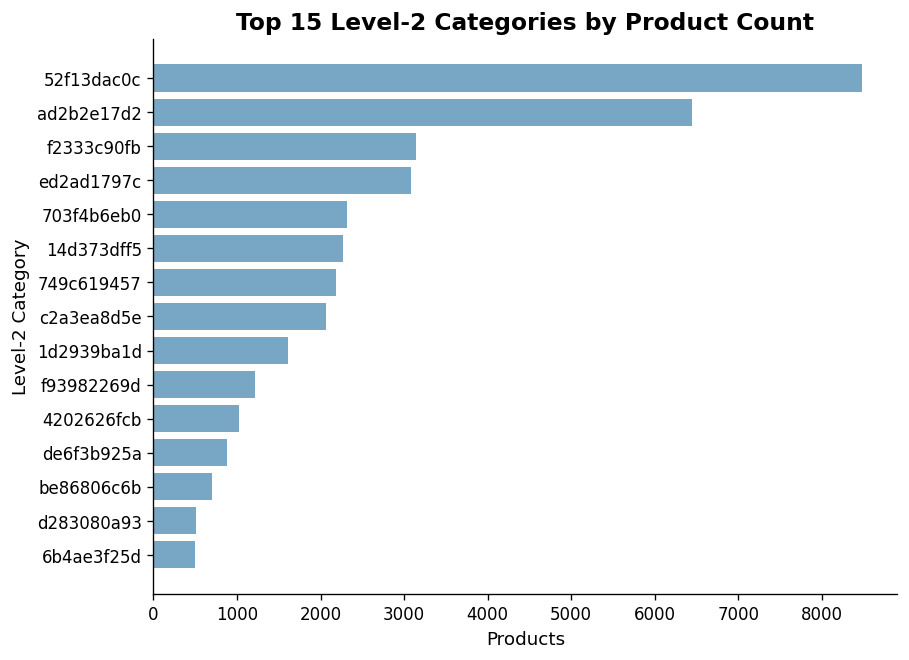

In [103]:
level_2_distribution = duckdb_connection.execute(
    """
    SELECT
        level_2,
        COUNT(*) AS products
    FROM products
    GROUP BY level_2
    ORDER BY products DESC
    LIMIT 15
    """
).df()

level_2_distribution = level_2_distribution.sort_values(
    "products",
    ascending=True,
)

plt.figure(figsize=(8, 6))

plt.barh(
    level_2_distribution["level_2"],
    level_2_distribution["products"],
    color=COLORS["serene_sea"],
)

plt.title("Top 15 Level-2 Categories by Product Count")
plt.xlabel("Products")
plt.ylabel("Level-2 Category")
plt.show()

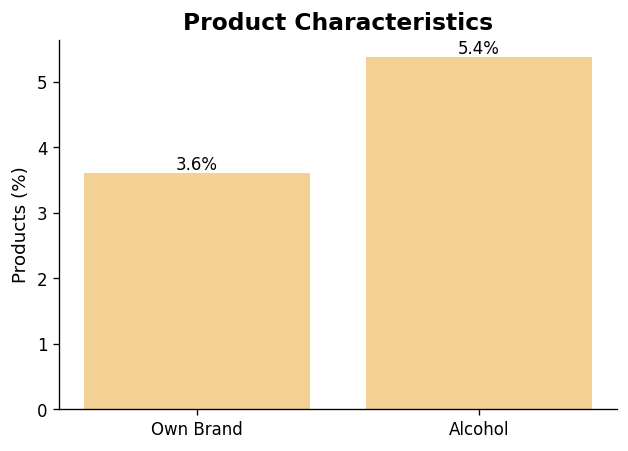

In [104]:
product_flags = duckdb_connection.execute(
    """
    SELECT
        100.0 * AVG(is_own_trademark) AS own_brand_percentage,
        100.0 * AVG(is_alcohol) AS alcohol_percentage
    FROM products
    """
).df()

product_flag_distribution = pd.DataFrame({
    "product_type": ["Own Brand", "Alcohol"],
    "percentage": [
        product_flags.loc[0, "own_brand_percentage"],
        product_flags.loc[0, "alcohol_percentage"],
    ],
})

plt.figure(figsize=(6, 4))

bars = plt.bar(
    product_flag_distribution["product_type"],
    product_flag_distribution["percentage"],
    color=COLORS["bungalow_maple"],
)

for bar, percentage in zip(
    bars,
    product_flag_distribution["percentage"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.title("Product Characteristics")
plt.ylabel("Products (%)")
plt.show()

### Broad EDA Findings

- Gender coverage is incomplete. Nearly half of customers are unknown (46.4%). Among known records, females (36.8%) significantly outnumber males (16.8%). While gender provides useful signal, the large missing segment must be handled carefully in modeling.

- Customers span a wide age range (25–70 years) with two main peaks around 30–40 and 55–65.

- Weekly purchases are steady, except for minor changes in late December and a rise in early March. The low counts in the first and last weeks are simply due to incomplete weeks.

- Purchases are well-distributed across stores. Even top-performing locations have similar sales volume, showing customers shop across a broad network rather than a few main stores.

- The product catalog is deep and hierarchical. It starts with 4 broad Level-1 groups (mostly concentrated in two) and expands down to 784 detailed Level-4 categories. Level-2 categories are uneven, dominated by a few large groups.

- The catalog features thousands of brands (4,184) and vendors (3,137). In contrast, own-brand items (3.6%) and alcohol products (5.4%) represent only small fractions of all products.

Overall, RetailHero covers a diverse mix of customers, stores, and products. Because shopping patterns vary widely across customer profiles, the next logical step is to aggregate the data down to customer-level behavior.